In [1]:
pip install pandas numpy matplotlib scikit-learn jupyter

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.7 MB 11.0 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.7 MB 11.5 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.7 MB 11.6 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.7 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 11.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------- -------------------------------- 2.4/12.3 MB 12.0 MB/s eta 0:00:01
   ---------------- ----------------------- 5.0/12.3 MB 11.8 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.3 MB 11.2 MB/s eta 0:00:01
   ------------------------------- -------- 9.7/12.3 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.3 MB 11.4 MB/s eta 0:00:01
   ----


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd

df = pd.read_csv(r"C:\Users\NaderV2\Desktop\customer-segmentation-project\data\mall_customers.csv")
print(df.head())
print(df.shape)
print(df.columns)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
(200, 5)
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [22]:
df.columns = [
    "CustomerID",
    "Gender",
    "Age",
    "AnnualIncome",
    "SpendingScore"
]

df.head()


,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


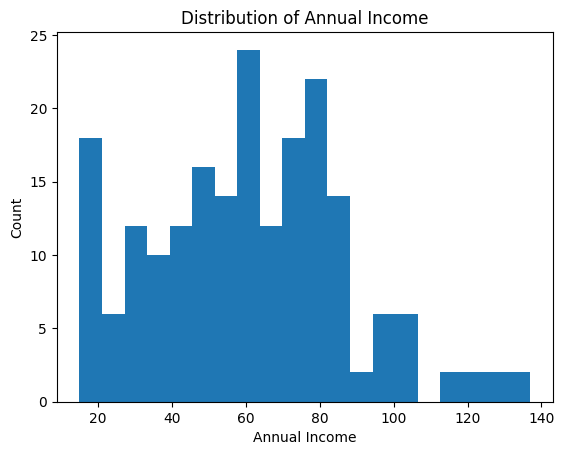

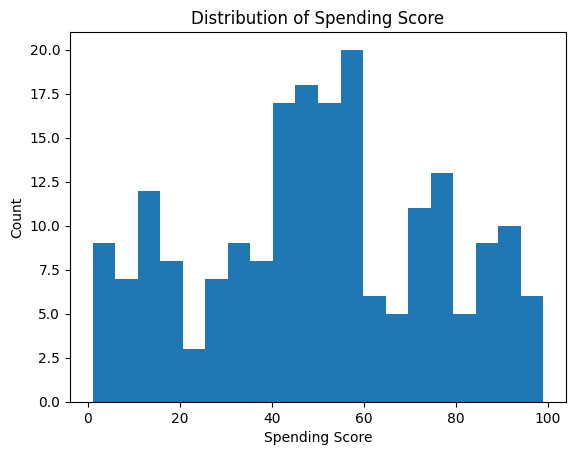

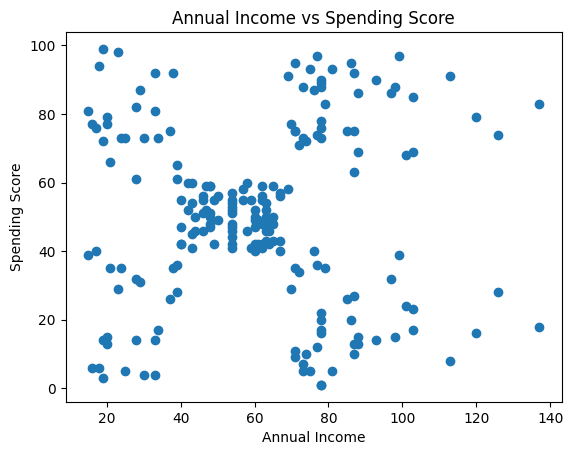

In [23]:
import matplotlib.pyplot as plt

plt.hist(df["AnnualIncome"], bins=20)
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

plt.hist(df["SpendingScore"], bins=20)
plt.title("Distribution of Spending Score")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.show()

plt.scatter(df["AnnualIncome"], df["SpendingScore"])
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [26]:
X = df[["AnnualIncome", "SpendingScore"]]
X.head()

,AnnualIncome,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

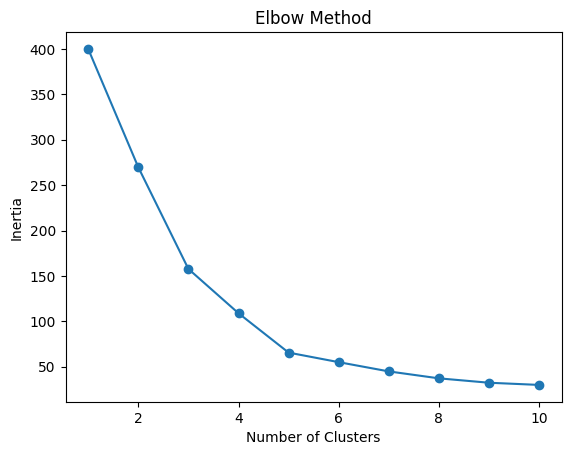

In [30]:
from sklearn.cluster import KMeans

inertia_values = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_values.append(model.inertia_)

plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

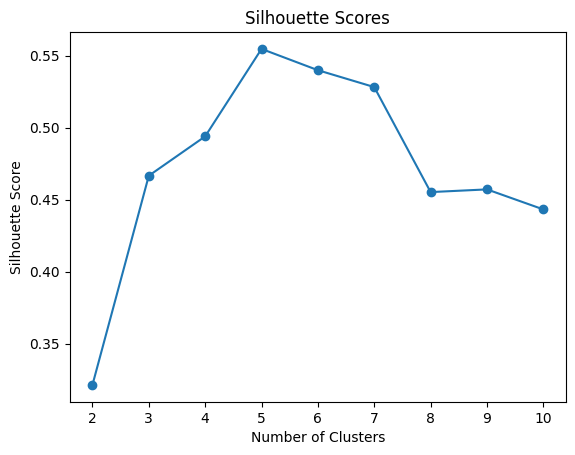

In [31]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(k_range, silhouette_scores, marker="o")
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [32]:
best_k = 5

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

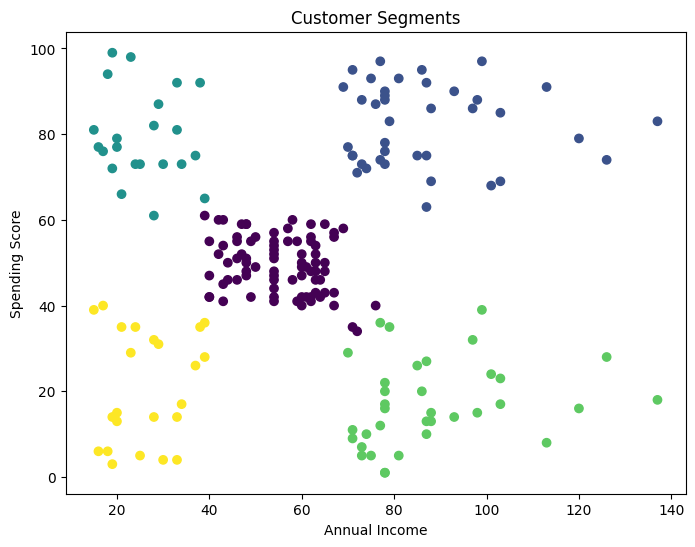

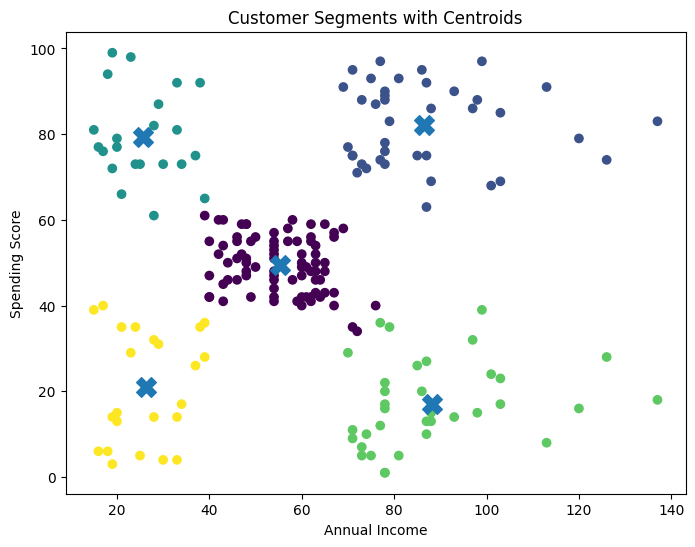

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(df["AnnualIncome"], df["SpendingScore"], c=df["Cluster"])
plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(df["AnnualIncome"], df["SpendingScore"], c=df["Cluster"])
plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=200)
plt.title("Customer Segments with Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster")[["Age", "AnnualIncome", "SpendingScore"]].mean()
print(cluster_summary)

#Cluster 0 (Medium Income, Medium Spending):
#Represents average customers with balanced purchasing behavior.
#Strategy: Maintain engagement through standard promotions.
#Cluster 1 (High Income, High Spending – High Value Customers):
#These are premium customers generating the highest revenue.
#Strategy: Focus on retention through loyalty programs and personalized offers.
#Cluster 2 (Low Income, High Spending – Young Spenders):
#Likely impulsive or trend-driven customers with high spending despite lower income.
#Strategy: Target with marketing campaigns and promotions to maximize revenue.
#Cluster 3 (High Income, Low Spending – High Potential Customers):
#Customers with strong purchasing power but low engagement.
#Strategy: Increase conversion through targeted incentives and premium offers.
#Cluster 4 (Low Income, Low Spending – Low Value Customers):
#Low contribution to revenue.
#Strategy: Minimize marketing costs or target with low-cost campaigns.

               Age  AnnualIncome  SpendingScore
Cluster                                        
0        42.716049     55.296296      49.518519
1        32.692308     86.538462      82.128205
2        25.272727     25.727273      79.363636
3        41.114286     88.200000      17.114286
4        45.217391     26.304348      20.913043


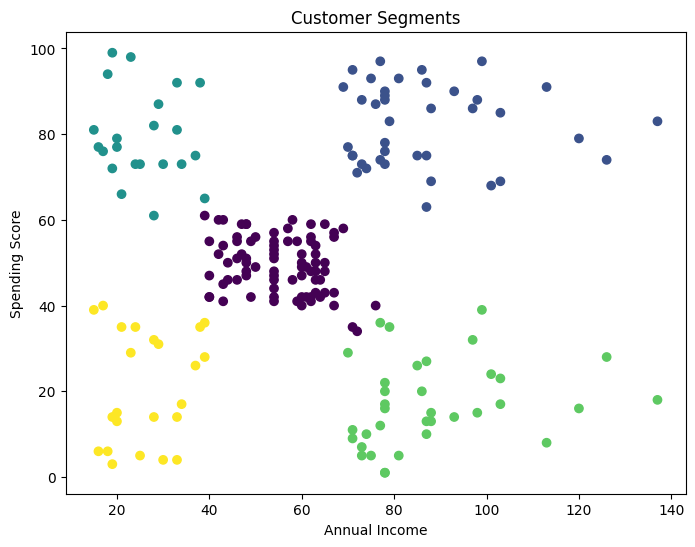

In [40]:
cluster_summary.to_csv(r"C:\Users\NaderV2\Desktop\customer-segmentation-project\outputs\cluster_summary.csv", index=True)

plt.figure(figsize=(8, 6))
plt.scatter(df["AnnualIncome"], df["SpendingScore"], c=df["Cluster"])
plt.title("Customer Segments")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.savefig("../outputs/customer_segments.png")
plt.show()